# Lesson 186 · Production constraints

Complete 81-cell course simulation plus original 300-receipt audit. No package install, network call, cloud dispatch or trained model. Implement three live contracts, run every cell, and defend the missing production evidence.

In [ ]:
from pathlib import Path
import bisect, hashlib, itertools, json, math, random
from collections import deque
print("Hypothetical serving simulation; new cloud/API spend $0")

<p class="mission-tag">From benchmark evidence to a serving contract</p>

A relational model can score well offline and still return an answer too late—or return a quick answer based on old related rows. Your tangible win today: **write a contract that checks response time and relational information age separately**.

**Route:** 15-minute core reading, then a 35–45-minute lab. You need query identity and temporal cutoffs from [Lesson 175](https://avistian.github.io/relational/lessons/0175-zero-shot-evaluation.html), context and batch evaluation from [Lesson 176](https://avistian.github.io/relational/lessons/0176-few-shot-icl-evaluation.html), and nested timers from [Lesson 177](https://avistian.github.io/relational/lessons/0177-compute-budget-realism.html). Each is recapped below. [Lesson 185](https://avistian.github.io/relational/lessons/0185-causal-relational-data.html) asks whether a prediction justifies an action; this lesson asks whether the required information can arrive in time. You do not need that lesson’s simulator to follow this one. No previous practical exit is marked complete here.

**Executed:** complete **81-scenario course simulation / 810,000 responses**, plus **300 original batch-receipt replays**. All service times are hypothetical. Live production performance, fresh model inference and paper-result reproduction are `NOT_RUN`; request latency from original batch receipts is `NOT_MEASURED`. Learner status: `PENDING_WRITTEN_DEFENSE`.

Recall the difference between a temporal cutoff and observed arrival, and between an inner timer and its enclosing timer.

## 1 · The missing contract

In an offline benchmark, features and predictions can already be on disk. At serving time, a customer request must find the customer’s orders, connect payments to those orders, form the model input, and return an answer. The slowest or least current dependency can determine whether that answer is usable.

Huyen distinguishes precomputed predictions, online prediction with historical features, and prediction using fresh features. These offer different ways to move work off the request path. Our lesson makes those choices executable with a deliberately small relational simulation. [Primary reading: Huyen, stages 1–3](https://huyenchip.com/2022/01/02/real-time-machine-learning-challenges-and-solutions.html).

<figure tabindex="0">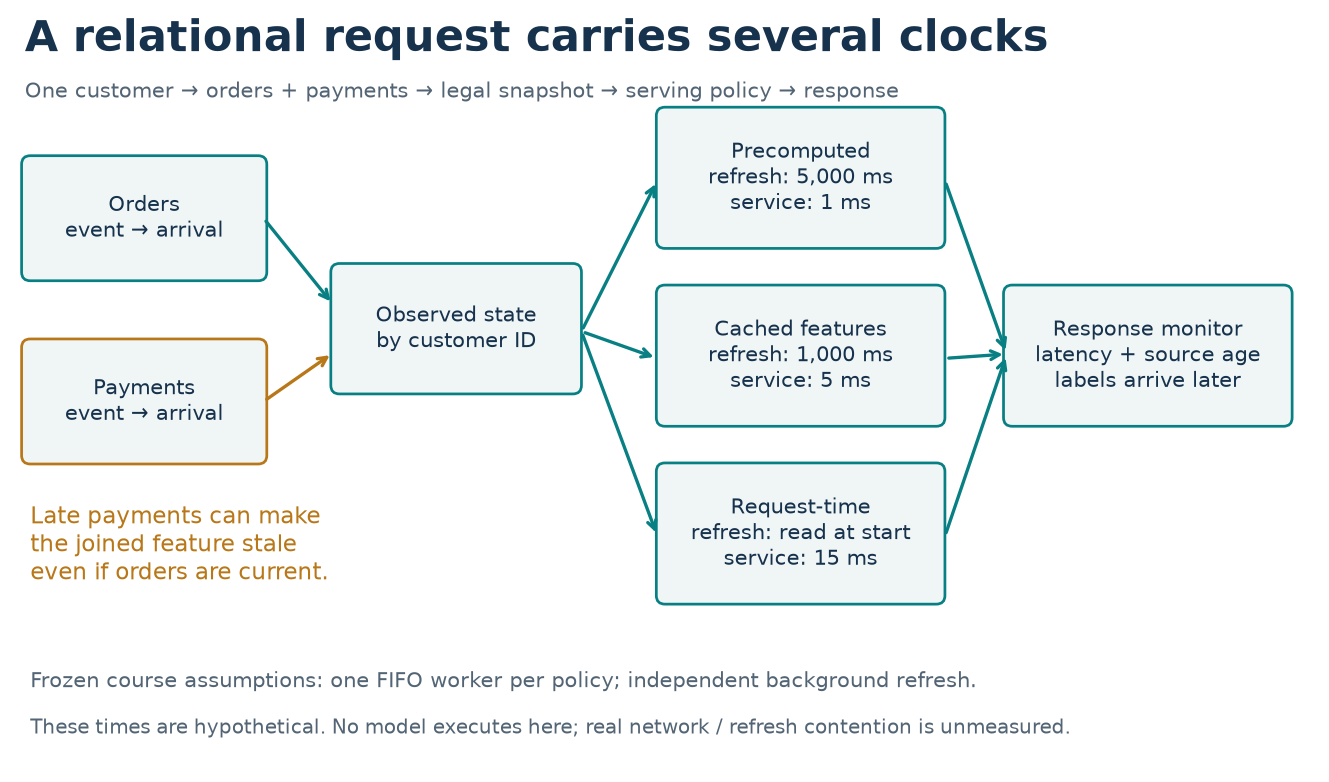<figcaption>Relational serving routes. All three policies read the same customer-linked dependencies; only their legal read time and assumed request cost differ. Scroll horizontally on narrow screens.</figcaption></figure>

This is a **serving architecture**, not a new model architecture. Twenty customer IDs join two upstream snapshot streams, orders and payments. We model when their state is available, not their business values or prediction accuracy. Production systems need additional measurements for network hops, real joins, model execution, shared refresh resources, failures and capacity.

## 2 · Follow four clocks

**Event time** says when a source snapshot describes the world. **Arrival time** says when our service can see it. **Materialization time** says when a derived feature or precomputed prediction becomes ready. **Response time** says when the caller receives the answer. Knowing an event’s timestamp does not prove we had received it then.

At service start, the request can read only dependency snapshots that have arrived. For cached policies, it sees only a refresh that has completed. Within each source, a late older snapshot cannot replace a newer one. For this fixture, each source update is a state snapshot: accepting the latest observed snapshot does **not** prove that every real transaction arrived.

We define:

- **Request latency** = response time − request arrival.
- **Observed source age** = response time − the oldest event time among required dependency snapshots.
- **Materialization age** = response time − materialization completion.

These definitions are course policy, with units of milliseconds. The source-age limit is conservative for this fixture; it is not proof of feature correctness. A missing dependency produces unknown source age and fails the freshness contract.

<figure tabindex="0">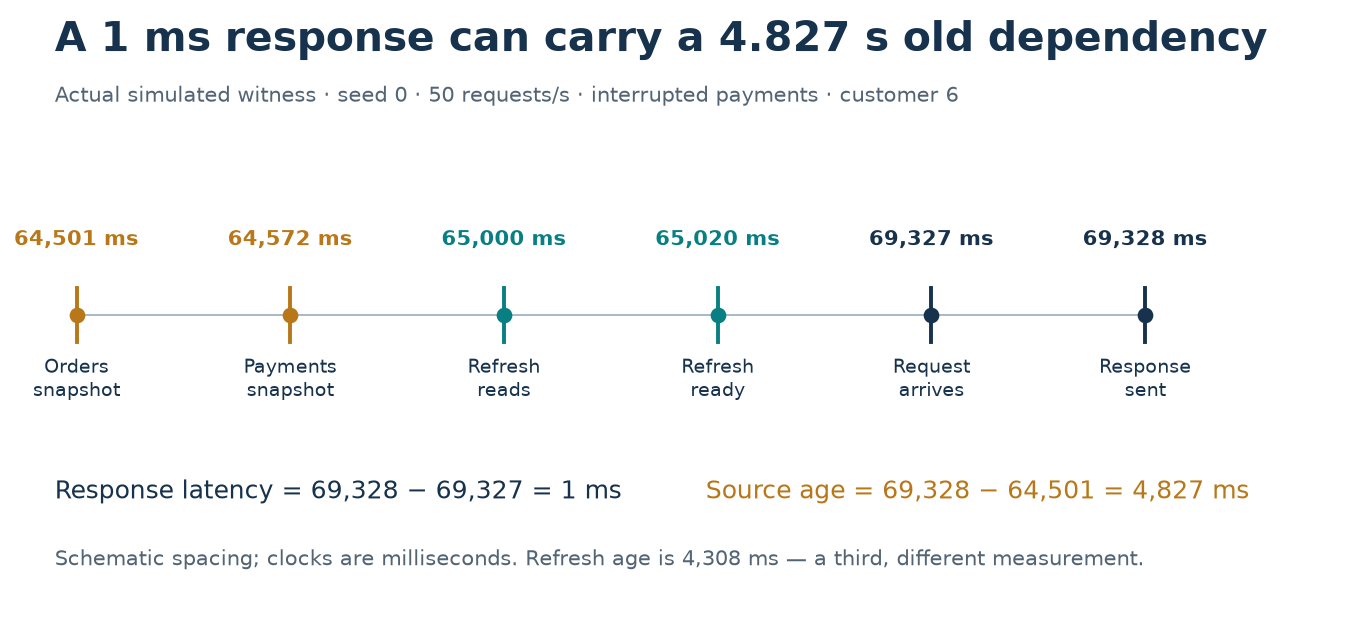<figcaption>A complete saved request trace. Event, refresh and response clocks show why a 1 ms response violates a 2,000 ms source-age limit. Scroll horizontally on narrow screens.</figcaption></figure>

Predict: can a 1 ms response contain a stale dependency? Explain using the two separate limits.

A fast cache can contain stale data. Conversely, a request can wait a long time in a queue, then read a recent snapshot at service start: its features are fresh at response but its answer is late. The chosen read point matters; a product requiring a snapshot as of **request arrival** needs a different information contract.

## 3 · Freeze the entire experiment

The executable target is **L186 Relational Serving Contract**, a course experiment. Huyen’s reading supplies design concepts, not numerical results to replicate. We run every cell in the frozen grid: **3 policies × 3 request rates × 3 arrival conditions × 3 seeds = 81 scenarios**, each with **10,000 requests**.

| Policy | Foreground service | Refresh | What waits on the caller’s path? |
|---|---:|---:|---|
| Precomputed prediction | 1 ms | Every 5,000 ms | Prediction lookup |
| Cached features | 5 ms | Every 1,000 ms | Feature lookup and nominal scoring |
| Request-time features | 15 ms | At service start | Nominal feature assembly and scoring |

All durations are **hypothetical constants**. Background refresh takes 20 ms on independent, unconstrained resources. No trained model runs. A single first-in, first-out (**FIFO**) foreground worker serves requests in arrival order. It serves every request to completion; there are no silent drops, retries, cancellation or autoscaling. Nominal rates are 10, 50 and 100 requests/s, with seeded, rounded exponential gaps. All three policies get exactly the same trace within each condition and seed. Bootstrap snapshots remain in the reported metrics; no warm-up responses are discarded.

Orders and payments publish state snapshots every 500 ms. Normal arrivals lag by 0–100 ms. In the middle third of the request horizon, payments either add 2,000 ms of delay or are held until the interruption ends. Orders continue. The simulation generates enough future source updates to drain the foreground queue. It cannot access those updates before their arrival.

The fixed limits are **100 ms request latency** and **2,000 ms source age**; equality passes. p99 uses the nearest-rank definition: sort 10,000 latencies and take the 9,900th. This is a finite-trace statistic, not an estimate with a calibrated production confidence bound. The three seeds expose trace variation; they do not cover hardware uncertainty.

<figure tabindex="0">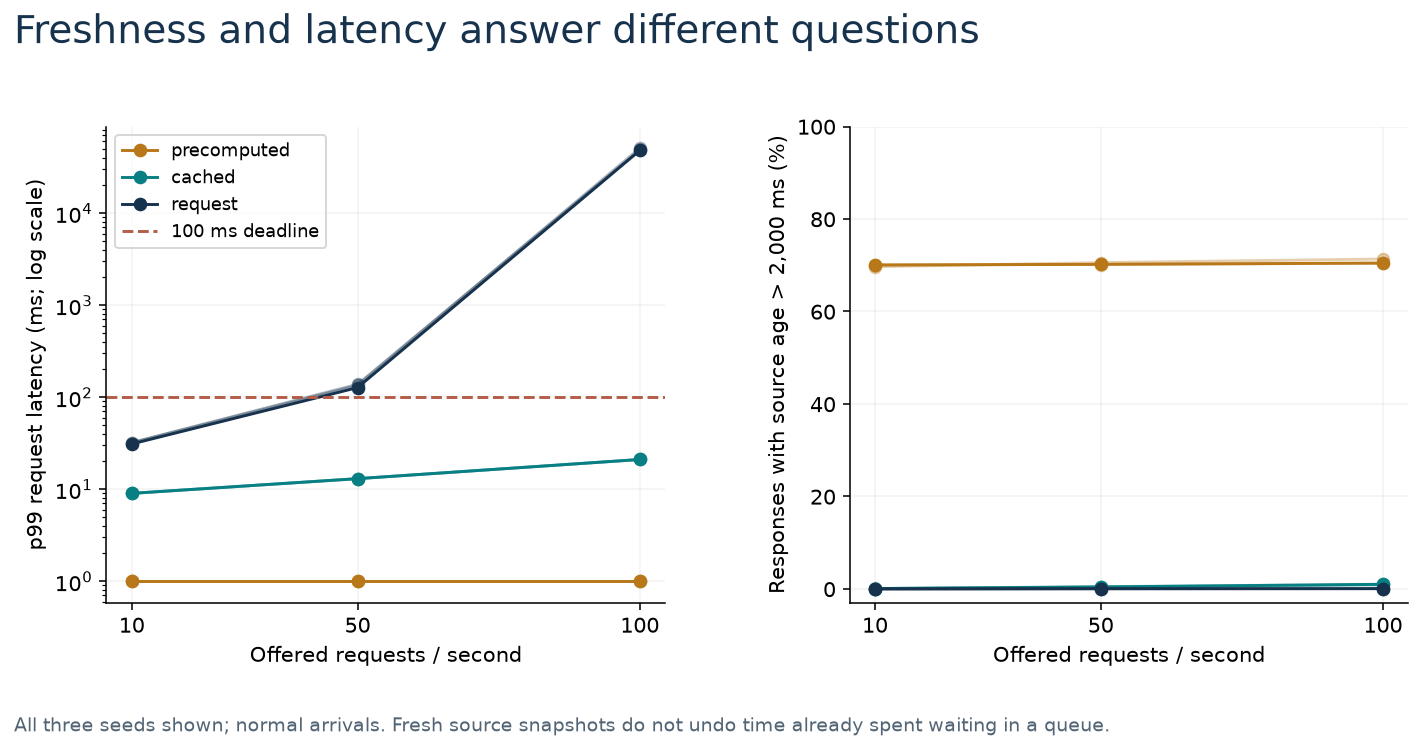<figcaption>Complete normal-arrival subset: three rates, three policies and all three seeds. Hypothetical worker times; these are simulated finite-trace results. Scroll horizontally on narrow screens.</figcaption></figure>

| Policy · normal arrivals · seed 0 | Requests/s | p99 latency | Deadline misses | Stale responses |
|---|---:|---:|---:|---:|
| precomputed | 10 | 1 ms | 0.00% | 70.05% |
| cached | 10 | 9 ms | 0.00% | 0.08% |
| request | 10 | 31 ms | 0.00% | 0.00% |
| precomputed | 50 | 1 ms | 0.00% | 70.20% |
| cached | 50 | 13 ms | 0.00% | 0.43% |
| request | 50 | 127 ms | 2.87% | 0.04% |
| precomputed | 100 | 1 ms | 0.00% | 70.47% |
| cached | 100 | 21 ms | 0.00% | 1.00% |
| request | 100 | 47,983 ms | 99.71% | 0.06% |

This worked table shows seed 0; the figure includes all three seeds and the full report retains all 81 cells. No best seed or policy was selected.

**Utilization** compares arriving work with available worker time. At 100 requests/s, each request needs 0.015 seconds, so a 15 ms worker receives `100 × 0.015 = 1.5` worker-seconds of work per second: work arrives faster than that one worker can finish it. The observed finite-trace queue grows. Freshly reading dependencies cannot recover the already spent waiting time. Independent background refresh capacity favors cached policies in this experiment; measuring that cost is required before making a deployment decision.

## 4 · Change an assumption, predict, then inspect

Before selecting a new cell, predict whether the change affects queueing, source age, or both. Reset returns to cached features, 50 requests/s, normal arrivals, seed 0. The explorer displays complete saved cells; it does not interpolate a new result.

Use the scenario selection cell below to inspect complete saved cells. Predict a change before inspecting the output.

**Try:** hold rate and seed fixed, switch from normal to interrupted payments. Then switch policy. Can any policy make an unavailable payment snapshot arrive sooner? Why can the request-time policy have a lower stale-response fraction at high load? Check that it drains after the incident ends; this aggregate mixes different response times and is not evidence of better incident handling.

## 5 · Monitor what you can actually observe

Monitor latency, traffic, errors and saturation to understand the service. Here, deadline misses and queue wait expose operational trouble. Real error rates and resource saturation need instrumentation absent from this simulation. [Google SRE, monitoring distributed systems](https://sre.google/sre-book/monitoring-distributed-systems/).

Our freshness monitor examines the last 100 completed responses. It triggers only when **more than ten** are stale, after a complete window exists. This is a response-count window: at lower traffic, accumulating 100 observations takes longer. It is not a fixed-duration detector.

Report whether an alert was already active at the injected onset. “First alert response after onset” can be almost immediate for a policy that was stale all along. That is not new fault detection. The report also records new false-to-true episodes. Recovery bursts, sparse observations and this fixed threshold limit what either time means.

Quality needs a separate clock. In the simulation, labels become available 30,500 ms after each request’s arrival. We count their availability at the final response but compute no accuracy: no scores or labels were generated. This artificial delay illustrates the contract; it is not an F1 target window. Production scoring needs mature labels joined to the exact original request and model version. A latency or freshness alert alone does not establish model degradation. [Huyen, natural labels and monitoring](https://huyenchip.com/2022/02/07/data-distribution-shifts-and-monitoring.html).

## 6 · The real batch evidence answers a narrower question

We authenticate all **300 original L176 run receipts** and check the full two-task, three-model, five-context, ten-seed grid. Their batches contain 702 F1 or 825 trial queries. We compare individual JSON records with the phase receipts and reconstruct their timers independently using SQL.

**474.434 s** of inner evaluation time + **0.939 s** from 12 distinct loading events sit inside **491.471 s** of worker time. The difference is other worker work; it is not measured cloud startup. Do not add inner timers to the outer total.

Dividing a batch duration by its query count can describe amortized batch throughput cost. It cannot recover queueing, network or individual request latency. There are no per-request samples here, so request p99 remains **NOT_MEASURED**. This lane reads timing metadata, not checkpoint weights or saved prediction values. Hashes establish unchanged bytes, not the physical accuracy of the original clocks.

## 7 · Lab: implement three contracts that control the result

Open the [student notebook](https://avistian.github.io/relational/labs/0186-production-constraints.ipynb), [rendered executed solution](https://avistian.github.io/relational/labs/html/0186-production-constraints.html), or [solution notebook](https://avistian.github.io/relational/labs/solutions/0186-production-constraints.ipynb). The portable notebook embeds the receipt packet and visible simulator. It runs offline using the Python standard library, with no cloud call or model download.

1. **FIFO schedule:** include time spent waiting behind earlier requests. Return every start and finish time.
2. **Dependency source age:** use the oldest required snapshot; keep missing information unknown.
3. **Freshness alert:** require the full trailing window and the strict threshold.

All three functions are called by the full 81-scenario run. An independent author check reconstructs every response using indexed prefix maxima and a different queue recurrence. Passing notebook checks is preparation for the written defense, not proof of learner mastery.

Implement the FIFO contract in the TODO cell below.

**CHECK:** serve arrivals `[0, 2, 30]` with 10 ms service. Starts are `[0, 10, 30]`, finishes `[10, 20, 40]`, latencies `[10, 18, 10]`. Then change one dependency event from 90 to 60 at response time 100: the source age must increase from 20 to 40 if the other dependency is 80.

## 8 · Exit: write the fallback, not just the threshold

Write a six-sentence serving contract: required relational keys, snapshot/read point, response deadline, freshness limit, fallback action, and monitoring/label policy. Choose whether stale or missing dependencies cause abstention, a baseline response, or an explicitly marked stale answer. The simulation reports breaches; it does not execute or prove the quality of your proposed fallback.

Defend one choice under interrupted payments and another under overloaded request-time service. State the real measurements still needed before deployment. Tomorrow, recall the four clocks without looking. In a week, explain why batch throughput cannot establish request p99.

Write the six-sentence contract in the EXIT cell below.

**Ask the teacher** about any unclear trace, metric or assumption. Bring your written contract for feedback.

[Quick reference](https://avistian.github.io/relational/reference/production-constraints.html) · [Frozen protocol and commands](https://avistian.github.io/relational/labs/l186-reproduction.md) · [Complete report](https://avistian.github.io/relational/labs/evidence/l186/report.json) · [Independent verification](https://avistian.github.io/relational/labs/_verify_l186_results.json) · [Source ledger](https://avistian.github.io/relational/labs/sources/l186/source-ledger.json) · [Curriculum and the next privacy lesson](https://avistian.github.io/relational/reference/curriculum.html)

**Next: [Lesson 187](https://avistian.github.io/relational/lessons/0187-ethics-privacy-reg.html).** A response can meet its deadline and freshness limit while exposing a person’s information. Extend the serving contract with a protected unit and a precise release rule.


## PROVIDED · Frozen protocol
The timing numbers below are hypotheses, not L176 measurements. Use the approved 81-cell grid unchanged for the complete report. Any changed experiment needs a new identity.

In [ ]:
CONFIG = {'requests': 10000, 'entities': 20, 'rates': [10, 50, 100], 'seeds': [0, 1, 2], 'conditions': ['normal', 'delayed', 'interrupted'], 'policies': {'precomputed': {'service_ms': 1, 'refresh_ms': 5000}, 'cached': {'service_ms': 5, 'refresh_ms': 1000}, 'request': {'service_ms': 15, 'refresh_ms': 0}}, 'refresh_work_ms': 20, 'event_interval_ms': 500, 'drain_margin_ms': 200000, 'deadline_ms': 100, 'freshness_ms': 2000, 'window': 100, 'threshold': 0.1, 'label_delay_ms': 30500}

## TODO · Schedule every request
Return (start,finish) tuples for one FIFO worker. Validate positive integer service and nonnegative ordered integer arrivals. Include queue wait.

In [ ]:
def schedule(arrivals, service_ms):
    raise NotImplementedError("TODO: schedule")

In [ ]:
assert schedule([0,2,30],10)==[(0,10),(10,20),(30,40)]
print('CHECK: second request waits 8 ms')

## TODO · Keep the oldest dependency visible
Return response time minus the minimum dependency event; if any is None, return None. Reject empty lists, future or noninteger events, and invalid response times.

In [ ]:
def source_age(response_ms, dependency_events):
    raise NotImplementedError("TODO: source_age")

In [ ]:
assert source_age(100,[80,90])==20
assert source_age(100,[80,None]) is None
print('CHECK: missing source does not become fresh')

## TODO · Wait for the complete monitor window
Require window positive, threshold in [0,1], Boolean flags. Use only the last window responses; strictly greater than threshold. No full window returns False.

In [ ]:
def freshness_alert(stale, window=100, threshold=.1):
    raise NotImplementedError("TODO: freshness_alert")

In [ ]:
assert not freshness_alert([True]*99)
assert not freshness_alert([True]*10+[False]*90)
assert freshness_alert([True]*11+[False]*89)
print('CHECK: strict threshold and complete window')

## CHECK · Behavioral contracts
These call your live implementations; the author verification separately rejects three plausible wrong implementations.

In [ ]:
def checks(schedule, source_age, freshness_alert):
    assert schedule([0, 2, 30], 10) == [(0,10),(10,20),(30,40)]
    assert source_age(100, [80, 90]) == 20
    assert source_age(100, [80, None]) is None
    assert not freshness_alert([True]*99, 100, .1)
    assert not freshness_alert([True]*10+[False]*90, 100, .1)
    assert freshness_alert([True]*11+[False]*89, 100, .1)
    assert not freshness_alert([True]*100+[False]*100, 100, .1)
    for fn,args in [(schedule,([2,1],1)),(schedule,([0],0)),(source_age,(10,[11])),(source_age,(10,[])),(freshness_alert,([True],0,.1))]:
        try: fn(*args)
        except (ValueError,TypeError): pass
        else: raise AssertionError('Invalid input accepted')
    return 'PASS'

In [ ]:
assert checks(schedule,source_age,freshness_alert)=='PASS'

## PROVIDED · Visible trace generator, legal reads, metrics and full runner
The simulation calls all three learner functions above. Every policy receives the paired trace. There is no hidden API or model. Original source: labs/relkit/serving_l186.py.

In [ ]:
def digest(value):
    return hashlib.sha256(json.dumps(value, separators=(',',':'), sort_keys=True).encode()).hexdigest()

In [ ]:
def make_trace(rate, condition, seed, config=CONFIG):
    """Same requests across all policies/conditions; same underlying events across policies."""
    rng = random.Random(seed)
    arrivals, customers = [], []
    clock = 0
    for _ in range(config['requests']):
        clock += max(1, round(rng.expovariate(rate / 1000)))
        arrivals.append(clock)
        customers.append(rng.randrange(config['entities']))
    onset, end = clock // 3, 2 * clock // 3
    rng = random.Random(seed + 1000)
    events = []
    for customer in range(config['entities']):
        for table in range(2):
            events.append((-4900, customer, table, -5000))
            offset = (customer * 17 + table * 71) % 101
            for event in range(offset, clock+config['drain_margin_ms'], config['event_interval_ms']):
                arrival = event + rng.randrange(101)
                if table == 1 and onset <= event < end:
                    if condition == 'delayed': arrival += 2000
                    if condition == 'interrupted': arrival = max(arrival, end)
                events.append((arrival, customer, table, event))
    events.sort()
    return dict(arrivals=arrivals, customers=customers, events=events,
                onset_ms=None if condition=='normal' else onset, end_ms=end,
                sha256=digest([arrivals,customers,events]))

In [ ]:
def summarize(rows, trace, config=CONFIG):
    """Nearest-rank latency quantiles and separate operational/label coverage."""
    def quantile(values, q):
        values = sorted(values)
        return values[math.ceil(len(values)*q)-1]
    onset = trace['onset_ms']
    alerts = [r['finish_ms'] for r in rows if r['alert']]
    transitions = [r['finish_ms'] for i,r in enumerate(rows) if r['alert'] and (i==0 or not rows[i-1]['alert'])]
    post = [] if onset is None else [t for t in alerts if t>=onset]
    edges = [] if onset is None else [t for t in transitions if t>=onset]
    before = [] if onset is None else [r for r in rows if r['finish_ms']<onset]
    latency = [r['latency_ms'] for r in rows]
    ages = [r['source_age_ms'] for r in rows]
    assert all(a is not None for a in ages), 'Full fixture requires all dependencies'
    return dict(requests=len(rows),p50_ms=quantile(latency,.5),p95_ms=quantile(latency,.95),
                p99_ms=quantile(latency,.99),deadline_misses=sum(t>config['deadline_ms'] for t in latency),
                stale_responses=sum(r['stale'] for r in rows),source_age_p95_ms=quantile(ages,.95),
                material_age_p95_ms=quantile([r['material_age_ms'] for r in rows],.95),
                max_queue_wait_ms=max(r['start_ms']-r['arrival_ms'] for r in rows),
                first_alert_ms=alerts[0] if alerts else None, alert_episodes=len(transitions),
                preincident_alert_responses=sum(r['alert'] for r in before),
                active_at_onset=bool(before and before[-1]['alert']) if onset is not None else None,
                first_post_onset_alert_ms=post[0] if post else None,
                post_onset_alert_delay_ms=post[0]-onset if post else None,
                first_new_episode_delay_ms=edges[0]-onset if edges else None,
                labels_available_at_last_response=sum(a+config['label_delay_ms']<=rows[-1]['finish_ms'] for a in trace['arrivals']),
                performance_monitor='NOT_SCORED',trace_sha256=trace['sha256'],response_sha256=digest(rows))

In [ ]:
def simulate(trace, policy, config=CONFIG):
    """Advance arrivals only to each legal read time, including completed refreshes."""
    settings = config['policies'][policy]
    times = schedule(trace['arrivals'], settings['service_ms'])
    state = [[None,None] for _ in range(config['entities'])]
    index = 0
    events = trace['events']
    def advance(read_ms):
        nonlocal index
        while index < len(events) and events[index][0] <= read_ms:
            arrival, customer, table, event = events[index]
            assert event <= arrival
            old = state[customer][table]
            state[customer][table] = event if old is None else max(old,event)
            index += 1
    refresh = settings['refresh_ms']
    # Bootstrap snapshot is ready before time zero.
    advance(-4900)
    cached = [s[:] for s in state]
    materialized = -4880
    next_tick = 0
    flags = deque(maxlen=config['window'])
    rows = []
    for request_id, ((start,finish), arrival, customer) in enumerate(zip(times, trace['arrivals'],trace['customers'])):
        if refresh:
            while next_tick + config['refresh_work_ms'] <= start:
                advance(next_tick)
                cached = [s[:] for s in state]
                materialized = next_tick + config['refresh_work_ms']
                next_tick += refresh
            deps = cached[customer][:]
            read_ms = materialized-config['refresh_work_ms']
        else:
            advance(start)
            deps = state[customer][:]
            materialized = start
            read_ms = start
        age = source_age(finish, deps)
        stale = age is None or age > config['freshness_ms']
        flags.append(stale)
        rows.append(dict(request_id=request_id,customer=customer,arrival_ms=arrival,
                         start_ms=start,finish_ms=finish,read_ms=read_ms,
                         dependency_events=deps,source_age_ms=age,material_age_ms=finish-materialized,
                         latency_ms=finish-arrival,stale=stale,
                         alert=freshness_alert(flags,config['window'],config['threshold'])))
    return rows

In [ ]:
def run_grid(config=CONFIG):
    results, witness = [], []
    for rate, condition, seed in itertools.product(config['rates'],config['conditions'],config['seeds']):
        trace = make_trace(rate,condition,seed,config)
        for policy in config['policies']:
            rows = simulate(trace,policy,config)
            results.append(dict(policy=policy,rate=rate,condition=condition,seed=seed,**summarize(rows,trace,config)))
            if (rate,condition,seed)==(50,'interrupted',0):
                onset = trace['onset_ms']
                picked = [r for r in rows if onset+1800<=r['arrival_ms']<=onset+2200][:3]
                witness.extend(dict(policy=policy,**r) for r in picked)
    return dict(experiment='L186 Relational Serving Contract',status='COMPLETE_COURSE_SIMULATION',
                cells=len(results),requests=sum(r['requests'] for r in results),config=config,
                results=results,witness=witness,boundaries=dict(timings='HYPOTHETICAL',
                live_production='NOT_RUN',fresh_model_inference='NOT_RUN',paper_result_reproduction='NOT_RUN',
                historical_arrival_identity='NOT_ESTABLISHED',learner='PENDING_WRITTEN_DEFENSE'))

## PROVIDED · Authenticate every original receipt
The packet includes all 300 per-run records, phase/cost receipts, original L176 timer code and its inherited artifact manifest. No probability arrays or checkpoint weights are needed for timing replay. Hashes protect identity; they do not establish original clock truth.

In [ ]:
import base64, io, zipfile
PACKET='...'
raw=base64.b64decode(PACKET)
assert hashlib.sha256(raw).hexdigest()=='3f3441da5e1471d2f30ef3a5af976183ea95e92fd1946943d32fedc7bc1ffe99'
E=Path('l186-packet'); E.mkdir(exist_ok=True)
with zipfile.ZipFile(io.BytesIO(raw)) as z:
    for name in z.namelist(): assert not Path(name).is_absolute() and '..' not in Path(name).parts
    z.extractall(E)
pins={'files': {'packet/_run_l176.py': '9d955c74fcf940cbb9ec04a5e2802ef2993ac38b66d3df49dc3a6b394489c33c', 'packet/evidence/l176/artifact-manifest.json': '6cc62e4486cfec4b816dfba33a79362ecdb9ceb02bb54be63401182bec999bf0', 'packet/evidence/l176/pilot-1/cost.json': 'bef66ac45c96ece0519a3b411e0f012fd86faf756ba1d0a15ead907f313f288f', 'packet/evidence/l176/pilot-1/receipt.json': '9e2512300a70378ad9ef0c7bfc7a24e00345ddd7e2d5a369916cc6fc71ac9697', 'packet/evidence/l176/pilot-1/rel-f1-RDBPFN-1024-0.json': 'ac8e72cffa7916ca472bf204075755428ad1698cf761b74b72c5dffb928e5f5f', 'packet/evidence/l176/pilot-1/rel-f1-RDBPFN_single-1024-0.json': 'f3ea654c877403d2c90cbad419f9861667f429c0a1400e72d23074ae490a27b8', 'packet/evidence/l176/pilot-1/rel-f1-TabICLv1.1-1024-0.json': '947f84d3b18cc0453457a7dcfe773950d93b443c7f7c3b383c4a91389aa997ab', 'packet/evidence/l176/pilot-1/rel-trial-RDBPFN-1024-0.json': '168d5f52611209163943d229efef1d10e21bb79351ea4d2eecc8ad72286d74b9', 'packet/evidence/l176/pilot-1/rel-trial-RDBPFN_single-1024-0.json': 'd1c30ec9c9dbc5fc0141bc90c60728801a6a6fe0e5e65d9d8c716c0f73319667', 'packet/evidence/l176/pilot-1/rel-trial-TabICLv1.1-1024-0.json': 'e70f17312af860a3308729f724319c3a18c690cde33554cb3ccb093a1a895450', 'packet/evidence/l176/remaining-1/cost.json': '867d40c90ed50ee2ec3326b42e2e6fb1f10d707343eeb667e3493ca766585f6f', 'packet/evidence/l176/remaining-1/receipt.json': 'c6d2773a29f852573e8f3f4385c1325ca384f155130b9b10918d4eb382483e3c', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN-1024-1.json': '19bc264daf1e427f29a98c22f3013ea6c3b2594781d3d66065227a167761bcb5', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN-1024-2.json': '6e8855336a0016a9231c8cdb3dc8af0ecc0dce37742b253e15a0c090ad226920', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN-1024-3.json': 'bbf60e808c171b329850632b2039af5e78a173c1b74a4f6112968c69e499a05e', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN-1024-4.json': '7a4c16cdfaf4cdc8ce29c122c4f2724055560c5e605cfb8c9d0c1a6c72067365', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN-1024-5.json': '100fb16edff86ad3a93a5556a6afb9d389295889198d5e9e09d95dd8366652f0', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN-1024-6.json': 'ce4b954b2da8c3da937f36ac2ad2d15f009c42a94f45e4519321beba20f5e76b', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN-1024-7.json': '1f2f579ba901ef0f1371956b52e5034d5dd61b7cfc99c456f033e5786469b654', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN-1024-8.json': 'b145bc0945f62a0d92cc048e75eee3d77796d22d4cf0e42da4419ee2a882a01d', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN-1024-9.json': '897e11357a19b16a054f2510e80923d5d06aea46ceeca377494f5ff77d178cbc', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN-128-0.json': '6dd84506f2dea37c712dd146ac71c3d3d5a74e25b533c0a89f5b880abc9c287c', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN-128-1.json': '0a9c1317ed7a0f5d0a34b2b0d8ff4b10f66e145df37ddb9d01532f4ab78e76b8', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN-128-2.json': '1848df1060655618890ff1658ad5cb5119d2e6477ef09206126b729c0c18d9db', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN-128-3.json': '75fceef4ff7587ff7ae6af2578333519db02cfe6dce5e7cce2a2928942e67e17', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN-128-4.json': 'b74ca21c28124851bd5bb976716310d794d3ad71706c5078e28c489c86d03d38', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN-128-5.json': '38f03c14bc534372fc149757a95f92b1ee0cd3cb5694ed7f033e5438424d3fdc', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN-128-6.json': 'd7901807195c74d088114b6075c4d42799e1efb7b87c57c80cfbf41e104dc08d', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN-128-7.json': '72f51ed6ca6d2311d3732940acf566b98510908f4ed78f061915900e89a2aa9a', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN-128-8.json': '19ce491b580020840deee5fd35f7c0fc7a58d31e15abd1903f4024453679c5c2', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN-128-9.json': '4ee0e4eab01713e3ca031ce7f1e58893fdb2a2ecba45f2fc9a366b02fa3eeba4', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN-256-0.json': 'b8c006f666a1cc5fff08fb0ad9737d484774c7f3ec82c87ed5c95fc4b1a62269', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN-256-1.json': 'e6d1b30cb9a98c459914cd08c5a115bbf6b44fb8834fc5988dbbe166e2128d42', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN-256-2.json': '9dce4fd2ad8043e7591f70432f2e4017263cc050ca669f7c92cfef808d245448', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN-256-3.json': '68aa300263d9df4e5dbfbab32019b74caa825d0de27cc6e00bb7fde0e009dca9', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN-256-4.json': '35fa6e3b774c639a07f86ee09719d6b4e58dadb5699c4152174da68683ebd19d', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN-256-5.json': '3738c413a16eff5460c1630bd45d7307a76c4aacf37130aa5fda5e310b9cad97', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN-256-6.json': '1aa9fbc6f0d48a9936a900dea68c7f13008a2cb01421dd948dbce33702cfbef1', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN-256-7.json': '75cba747bb4a1399413ce93d095c7114be3503a9a8004f7a2139060d273f0ae0', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN-256-8.json': '56d9d8dcaee7b02442123c1544b5f83a0ae9364a641d3f84ab68ec60bb85a861', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN-256-9.json': '68e08dc52f59155c1e4cb8ece19182bc13e604a819312fd6c59dd19d2a8b3573', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN-512-0.json': '27f6dc38dfbce762c3cd8e80af5418a18e3ac37ebd7bdcec4ea60728aa79eb53', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN-512-1.json': 'd67e8ab36aa64b884516e571a3ae7e834f5370d78c0e76c0e652e153afd8278a', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN-512-2.json': '5bebf6ab12a6ef327bf2c25fa3ca34e7e56a2f85abe8f5e416d357e2ba745d06', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN-512-3.json': 'a4b2cf16915b17fc9d05041169fbf93aedbd19507ff1c56038043bd6f46f208e', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN-512-4.json': '3df11e72bd48087962e32a8ad9f7bbc019784b91e06a297c169788b1a7397829', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN-512-5.json': '9df0344fefe7f7cfe6b5118e6af68bfc6334dffbb4efb608395bd033ee5257a0', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN-512-6.json': '1b1f000ab3484a7d89637d5d3a15cbb9e5753c61446a60397b424b57279818df', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN-512-7.json': '1f1d2884e0222a94e72516a6b6d8ab2aa3cb511833edafd961f6b043a0dcdc95', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN-512-8.json': '1192cb9f0fdbae1fe72688140e7ccfce62b7ee82a89719a4b8b5e2cc0aab8e21', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN-512-9.json': '55d866a87d014faa20f9bd83c41e89fc6987f8da83e97b61e955397d1f497f2d', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN-64-0.json': 'f9006b89cfc24709af7d42b16fb262368afa2ea1a5132f7b94373633bae96a7c', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN-64-1.json': '8d527e2532541d3e95959a5f7394dc15e8cc54873ed8dd3d42c13e5ec25384ee', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN-64-2.json': '6b67986ae10fd959391ca476b463e1fd612e42c4f76f40fded906636d00c18ba', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN-64-3.json': '12f479aa6852f8da9528ab552b4cd01ba06a903b54c8c521e8810db1062ea21c', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN-64-4.json': 'a9fead17044d6d41a837817c80e3031d42e79400971ebbe678432efc34e25c29', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN-64-5.json': 'a9f245c38a1ebb505c14d09509ca096af3ed63453389ff1d7d86e1dfa7275bb4', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN-64-6.json': '38d3fcb4cde86d6677d47b9a451474ae08d866d23062e0944c72606fad1aca23', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN-64-7.json': '18fcd11cb231bb43f0aea2790a75c6e6044ca52646a6a6b685ae38e502f7dd52', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN-64-8.json': '4027530a16777d8a93ba758eeed3b8cdbb8fe4331fec4ec35645abdf9b80aa41', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN-64-9.json': '619d6cecb37d3e14cf0bb6b13ca5cf21fcd85d04ee63abe53a380b5d1b2a6da5', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN_single-1024-1.json': 'd216fb75f420971b5c89157825d2223561afac539b92b5bc7c14f98f91e13f3b', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN_single-1024-2.json': '552664f70b909b847247b4588adc5a9be3d07fd4fb1ecabfc7841e9c76135acb', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN_single-1024-3.json': '6e249a5917715bbf9a9cd910e8761635c5592b92aab79f59398c1378382f3a20', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN_single-1024-4.json': '4faefc37feb6c14828a36c9ea7de11cbe94690d806b56d244443d31d23ea5679', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN_single-1024-5.json': '3b19eefb04a000d12df8ce0dd8f1b2b97d66b31c0a48a3d0b84ef7dc58490bf3', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN_single-1024-6.json': '5f0e6eb7ea39e0660c2065d5d42d9e1015d1afd10b9396bffafd8cc0d05434a8', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN_single-1024-7.json': '3f8b2277a68345eaef120835448184b6b81ecfdd56aa9b677c4c13db72121274', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN_single-1024-8.json': '6ab024c9727a1a266edd7f850b8b2456535eb8bebdff70cb2d8cd3bf116fc8ad', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN_single-1024-9.json': '3c5425bcd364d62914bbdb37fa9045eeb2c47d0686ba8d64e8812493addd66ac', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN_single-128-0.json': 'bab1983e8a34806a40ecfa08d30835423a48832954c25a4a095f399ee9bbcbe9', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN_single-128-1.json': '801bee91b72b25b51c013835329340a35e7660bd5a274ccd8178fa66babe2844', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN_single-128-2.json': '0a80dfc8b09c02ae99fbd583b0df180f3151d97a5ff96dc7245623a0d2df21a1', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN_single-128-3.json': '79ffbcbf6a2b3c2640c6a017534f69120c5fad16e4c372c01f1d6847f22e025f', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN_single-128-4.json': '6059276d9ddf653e78eeaa89ef504484205cb25d1cc4df22c38de4b3955e8a14', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN_single-128-5.json': '9253565d7a20621eec30a94df3ef1caeb96972962031beacd0b733cd3f741852', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN_single-128-6.json': 'ce13e74f15a23a25384574b65b43a9e6820c6879aad78f2536b79c6c2da49968', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN_single-128-7.json': '2b2c4ee97aa805f0ef3b28c5814f163ffc5f7915e1bf24ebe2cf2f8d5e8f1399', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN_single-128-8.json': 'd1804c4aa3293261c0eb19d5764781a7da4cb63914f92c99d0011404fa463084', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN_single-128-9.json': '86221feafda5f77ddc90805d7aed3f0d2db33071aa10807e5b3e4187ddaac174', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN_single-256-0.json': 'c3d87d1e42d94feb70e74b9be624b53a1c31d67e331fd038d7d3ec8d6975d5b3', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN_single-256-1.json': 'ce50244e3d9ac170ef6bac76d83af0440447b6740134d2837c733e79979515ed', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN_single-256-2.json': '8d3edeb838ae12707f5c2101e8e576f947e24aa8345df9732be2831983e0884a', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN_single-256-3.json': '3f9c34c84744d9c6c410b42c5cd25d2293ae0e32c41774cd21f231b335f75092', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN_single-256-4.json': '4ea7d0c02af72c55793e1d9ebd0219068fd0651787e7a630768d94a2e5d294c3', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN_single-256-5.json': '9355c6af0b231a133b5905c16eb8e05e05cf1983a5df9e3c9322c3373804b24e', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN_single-256-6.json': '7c383729cff6ae19deade1ab44f8c636ba41296c5e4b0f4c2bcc4b97efd61c66', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN_single-256-7.json': '805a48e94e08ee283021f6b789822ec8af8dc7a81bf84328f91e37908acc35ca', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN_single-256-8.json': 'e25b3342fdb3deb9024fbadee091a33b0108a6835ca2804483fa72a1a0b5fc42', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN_single-256-9.json': '728cb376d205f51920f6f559945516c29a46e052fcbcec61900ba83930d5190d', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN_single-512-0.json': 'fef2d07d22e88dae019b119975430af96f93e9243777fc2c96fc166aefa2794d', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN_single-512-1.json': '8fd353882c5ff338a41a7bf7d15cf46fd2c2efce390304382f5ea741f00a1b44', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN_single-512-2.json': '3485ad8eaafd0624b285308c69313e1b3506820921fed67473cd8262601c0f6d', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN_single-512-3.json': '6e7936ad5be44e4d57ec1421ca99d3dfabddfe1633c95d8a16129ab761f6413a', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN_single-512-4.json': 'cdc482dad3dbad767ae38f0eb028a2d975f04d2d7cde87ca51a8a0b8bd57bc57', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN_single-512-5.json': 'f381dfd4655fe194da81b94b5cf4298c53a74c93d24fd0efa0ed610be2e8b251', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN_single-512-6.json': '7a25d1755d43660240994d46aba1383ed68cb86a6f845074a4289621654dec6c', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN_single-512-7.json': '43f55a644f76e30db18f847a16eed4891eaa2717117aaf55adde5aaf1c931e7d', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN_single-512-8.json': 'cff9c2f991f1e22571448a025de655352f56ee2221028fdb9a60576436e425ed', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN_single-512-9.json': '78fc2b1eaa276483d2262e6a182a4c3f69d84619410098a064eaf04abbb55d9b', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN_single-64-0.json': '69838eb80c00c5c8176e80329581d549ab89da6aeed23da5f1b161535ace726b', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN_single-64-1.json': '5f0a4ee73b20278f8436ae0ed0b8f4fd23f0469e6ad35db5c4fcb8411d683b0a', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN_single-64-2.json': 'cefbb4aea425db7ebf54b44610decafc2b583fc9e3652ba56c5f7162f7175d8b', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN_single-64-3.json': 'c855fb0e36d802a756900ef2c8fc5c09aa530ce63d19e31086aeabd587155e9b', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN_single-64-4.json': '83d51dc353974f41a1f140f4f5dd970f93a7fa56ec882584f4312336124b4120', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN_single-64-5.json': '3eb1db2dd6c174dac03a677f5fecfa92d9e7f2e4beca273fdfffc1d1d5cf967f', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN_single-64-6.json': '7b4cdeae6739075ac079c7662c64c88f311ebc5e2489da9bd4b20b3a7dd23e6d', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN_single-64-7.json': '5528de8f239ee94e368cbc76bdd0badf8a5a68b91539aef39c6566f660904688', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN_single-64-8.json': 'f1d7861459b2d63a98886d770436df1e8d3e062959e2660925b4846ee489c027', 'packet/evidence/l176/remaining-1/rel-f1-RDBPFN_single-64-9.json': 'bda7c66938196d250212f11877cd67f4dde93ae4fc2ab0fd9959dabb92fda50f', 'packet/evidence/l176/remaining-1/rel-f1-TabICLv1.1-1024-1.json': '5fe342e7113bb33dd78e232e9ca04b1da5db88e3c4e40c98608fbcdfd6c469fa', 'packet/evidence/l176/remaining-1/rel-f1-TabICLv1.1-1024-2.json': 'c52b1f0e9fe5311eead1cdfe650afa19a536b929b978ae54cd9d6b617b7fbf0f', 'packet/evidence/l176/remaining-1/rel-f1-TabICLv1.1-1024-3.json': '445e3c26913f33731c98711530a3b4a0ae41d83d4e81d3ab8b3419dea9a5b233', 'packet/evidence/l176/remaining-1/rel-f1-TabICLv1.1-1024-4.json': '1edb500053dc0147840c8eed1c63e50396da8e2c5221be231405dfd591c87286', 'packet/evidence/l176/remaining-1/rel-f1-TabICLv1.1-1024-5.json': '1b2550f42143b8b89f729f6f2e1ba6324d785cd022426edce189928e683b3dbe', 'packet/evidence/l176/remaining-1/rel-f1-TabICLv1.1-1024-6.json': 'ff830e48c0a3c5f27dbb59749dfea237d996c51d56033a1b4f900426ba3a0417', 'packet/evidence/l176/remaining-1/rel-f1-TabICLv1.1-1024-7.json': '3744aeee8fc4f2ba71787537eb6bcbad0613108f6b51b591a98ad90956e4af40', 'packet/evidence/l176/remaining-1/rel-f1-TabICLv1.1-1024-8.json': 'ab07cc3f5827439777584659ea57c1f7e98f02367e5d8182549523325de24538', 'packet/evidence/l176/remaining-1/rel-f1-TabICLv1.1-1024-9.json': '37f1ea9b79d3013fb89044f2a9968ad21a544e61c191afc4d66be2e9efbcc03e', 'packet/evidence/l176/remaining-1/rel-f1-TabICLv1.1-128-0.json': '96164fde2415f626155b885ce700a8899b59f7046d3811af2983fdc5dc31aa53', 'packet/evidence/l176/remaining-1/rel-f1-TabICLv1.1-128-1.json': 'a91cde937465e5d953ea79ff072358ca436ef155c34892e3673869f564f72ee4', 'packet/evidence/l176/remaining-1/rel-f1-TabICLv1.1-128-2.json': '52574b6e7376fd1f0afe2c54203ec52dac22fba2c4dc80b307fb85888211303f', 'packet/evidence/l176/remaining-1/rel-f1-TabICLv1.1-128-3.json': 'fa564183e5f6a5ba7bc754e7f1b0ecd9a0170048d198c7f81b64a325d1793b2a', 'packet/evidence/l176/remaining-1/rel-f1-TabICLv1.1-128-4.json': 'fad2d963bb46127f4ea667344d1a9182fc28efacee20895e381b9b0103a4e365', 'packet/evidence/l176/remaining-1/rel-f1-TabICLv1.1-128-5.json': '15d5ad4608407666abde9a60ceef472f173b0863fdbf5d404762236a94877462', 'packet/evidence/l176/remaining-1/rel-f1-TabICLv1.1-128-6.json': '6ab23ed54adbc7470f5fc88107962c91e2f18c6f8e674bc925e947c7e216d6a7', 'packet/evidence/l176/remaining-1/rel-f1-TabICLv1.1-128-7.json': 'ab3147f553621ab29ee332dfd01d4b1a74148c0fedefc20f032eae66ed059659', 'packet/evidence/l176/remaining-1/rel-f1-TabICLv1.1-128-8.json': '9159f8b18085ae672cc242d5b4fd33f638cf9655a0fdfd200285a186f87f4d6f', 'packet/evidence/l176/remaining-1/rel-f1-TabICLv1.1-128-9.json': 'd9172ebe7ca4fba5c687686d48fd33a63b617e4154fd96f04c1b66fea3368c6b', 'packet/evidence/l176/remaining-1/rel-f1-TabICLv1.1-256-0.json': '708128e7f19216e0b07a6302509a0b878dc27145caf659885e672875dd6914cc', 'packet/evidence/l176/remaining-1/rel-f1-TabICLv1.1-256-1.json': 'da483158045135c01a32f61ddcac21267d2c80bdc0863313249a47fbbdd8cdf3', 'packet/evidence/l176/remaining-1/rel-f1-TabICLv1.1-256-2.json': 'f3bfa5d8a851d837ddcc40ee8d9ffcae1d95d57399948234de263c143a14889b', 'packet/evidence/l176/remaining-1/rel-f1-TabICLv1.1-256-3.json': '888fdf572628d9d02c7c7ce7bb48ad92382b2e37bc5342dbb096ffe91abcc7d4', 'packet/evidence/l176/remaining-1/rel-f1-TabICLv1.1-256-4.json': '95aee0b1b4206462e40305df84ba45dd9282fa0f0c3114a5bddcbbd9ec4e5723', 'packet/evidence/l176/remaining-1/rel-f1-TabICLv1.1-256-5.json': 'f831c079a58ec835f4f1e2634299da50846bf5e086fe947bfe3503dddd5e2f01', 'packet/evidence/l176/remaining-1/rel-f1-TabICLv1.1-256-6.json': '28bb509957229eda3d0b7ab70b134965415844ccf7d98f8558d2b743bdb91c13', 'packet/evidence/l176/remaining-1/rel-f1-TabICLv1.1-256-7.json': 'c0f94ecf53bb1a3c895fc6a59c486db8ab91afec2b1eb6e0190e690290be340f', 'packet/evidence/l176/remaining-1/rel-f1-TabICLv1.1-256-8.json': '878e61486e5a56a505caaa5818c890d56db146e11847939b30f452e380cf97a8', 'packet/evidence/l176/remaining-1/rel-f1-TabICLv1.1-256-9.json': '0b0236d5ef4d7b0a768326d001bc87383dbd53c39af7863ba905413abb368cb7', 'packet/evidence/l176/remaining-1/rel-f1-TabICLv1.1-512-0.json': '7cb14a2169de5d11c033fa51f56c8baf5f1deef62e8d2967804436025fa42616', 'packet/evidence/l176/remaining-1/rel-f1-TabICLv1.1-512-1.json': '671a10d605780e4fa5e109dd099c6114a2c0ddf343c607f5aaa989625ff61170', 'packet/evidence/l176/remaining-1/rel-f1-TabICLv1.1-512-2.json': 'e699bb331c0ba53210a4019af5db29df35f358330252faa8a078cbce525b6290', 'packet/evidence/l176/remaining-1/rel-f1-TabICLv1.1-512-3.json': '46b35e0cc7c26e47c0dc4a801035eecfa5888dc32de9c55bd02b9ea6bca4cf4e', 'packet/evidence/l176/remaining-1/rel-f1-TabICLv1.1-512-4.json': '1137894de435dbf6eb004333b71ee7852d3e430d146a3bfd32ea77c9d20bdc4b', 'packet/evidence/l176/remaining-1/rel-f1-TabICLv1.1-512-5.json': 'fda9e74df6af14cb27ff95aedeb8722d83480449a18df173b963d241385d7e57', 'packet/evidence/l176/remaining-1/rel-f1-TabICLv1.1-512-6.json': '9cdd343ed9bbd5879d7a99d32e23b71957e0d110b54cba6d1bf0aa081c850c91', 'packet/evidence/l176/remaining-1/rel-f1-TabICLv1.1-512-7.json': '23b053c47c6f9805a8f2e4c110d05a97b01179db3e93784549b1442b11eee149', 'packet/evidence/l176/remaining-1/rel-f1-TabICLv1.1-512-8.json': 'f12cf76563218517e806be04c0b4fd22afa2b7e21af0aa702856dd55251b8a99', 'packet/evidence/l176/remaining-1/rel-f1-TabICLv1.1-512-9.json': 'ae5f8c714bbcdd99b9dd4f60b7a241031238d0f0c5e8132eb0719080dfc226e1', 'packet/evidence/l176/remaining-1/rel-f1-TabICLv1.1-64-0.json': '45fa754440de42fca15f22e1f34061389640bff46e6132f92d637a2e7e343e12', 'packet/evidence/l176/remaining-1/rel-f1-TabICLv1.1-64-1.json': '82116c24674b1c99b5b820a63618e0561c35271d4b82720caebe6f007c076459', 'packet/evidence/l176/remaining-1/rel-f1-TabICLv1.1-64-2.json': '05923dfc0d75049ca0b866b1632881efacd030c6ff77a7f0a5d097c73dd3aaca', 'packet/evidence/l176/remaining-1/rel-f1-TabICLv1.1-64-3.json': 'c45690d0c6476145266683ff3232ac71974926cec119854db702259c9209d02f', 'packet/evidence/l176/remaining-1/rel-f1-TabICLv1.1-64-4.json': 'c5108d6219f1668509fde751730823ad1639ed7af49ba506b8bf14f3795af738', 'packet/evidence/l176/remaining-1/rel-f1-TabICLv1.1-64-5.json': '1da4db4ae7dafb9c8800e3388c9fecf80b10e17a343a5db1ea13e77adee12f57', 'packet/evidence/l176/remaining-1/rel-f1-TabICLv1.1-64-6.json': 'bda1badc40ce59b4bbcebb6f7dee7cb927633bdec593b9177ed62840a97f3af7', 'packet/evidence/l176/remaining-1/rel-f1-TabICLv1.1-64-7.json': 'c7306400257e4de7ecf21850d3915552a685d921267e719bfce2ac616ca08100', 'packet/evidence/l176/remaining-1/rel-f1-TabICLv1.1-64-8.json': '16dfa8102f005e0e9bb89e35b094ebfb4a9dd2da14f7381d491b1804d7a81145', 'packet/evidence/l176/remaining-1/rel-f1-TabICLv1.1-64-9.json': '113e53928af89d62fb08ac267ac02713a6c57bc4094d077b63d05e1be7f851d4', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN-1024-1.json': 'fc9cc4320cd55e220b0bd99cb9c304e06bff424103ad0dd8fd4d15f65d2c5fa1', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN-1024-2.json': '43de0b1f665bb47ab2c72a32bb60921598d79aac95f4e3c2d42bc425913a0033', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN-1024-3.json': '14fd517922ccd4935239fdd4825d68e9fbeb77b9520b1c6ca99830e60bc46ec7', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN-1024-4.json': 'c83255835e176e8fda81ba32f34944d1febca51ef7557b3c75cb54762f5a1eb9', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN-1024-5.json': '34f03d3a4da16196a9a469b50f2a74eb55fcf91becdcf8dcdd9abc34f4b80dde', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN-1024-6.json': '3a10321b1a7a29ff6f514e7895427f04c443ec9808f4437860857a69fc04b846', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN-1024-7.json': '4b6aeeb227a233320fb422b5b677347cc9069d05c1ffeb3d566b816fcf8fce1f', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN-1024-8.json': 'ad97e6bb63f2c9990f20ff5f6803ea6640b053300271c2c8becc3b10621f2594', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN-1024-9.json': '1c541b3cdbcc05e9040ed3132db83d5330e1ccc8011af81d8c30b02a9816cfcc', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN-128-0.json': 'e7c3d4cf6565b2e78879b87f39e519760b9a238bcd3a555527aa7b11c7643666', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN-128-1.json': '4cb112717d01c9a4626ba1f0dd95f70227304d46f76166a3349ce316d02ba183', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN-128-2.json': '9b7844e900fdb20d65814596e990e86281c92349416e0919a7174b9dd3e23f11', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN-128-3.json': '5af49624cd673b97565a071599c7354ae46f02333b05ba2f6f1d84e1b8851c27', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN-128-4.json': '739e62a334711e0a581e8b276194a83a7a578753a2fc77bc09a5ac398c23d449', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN-128-5.json': 'a5e6b72eea28dde5c60c119819bd24fdf541e72cc5c5111d307fc9e1dc198147', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN-128-6.json': 'e2409b17fc9e1013275bded3733fbd334c4cff02ba111172da00cd0b4d352f74', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN-128-7.json': '43dbb43c89df35224cb7c0a4ed4bc29af0b03c92b1327dfe06d01abb9444f8e1', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN-128-8.json': '46d0b682139ca4384ab1099af5881bed9dce03bfa32eb98b61a3ef99b353efa2', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN-128-9.json': '23e4a95ee20d567dc052b3e5a589e9a7e271ffc23190172d156cea4c8d692e9d', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN-256-0.json': 'a52f20a7489ac2a64e90e3d8029dc0546e7cbe1127b18c940077cb9793b24ded', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN-256-1.json': '1b639f5f1656a51e92a4ba93792e67909a07f6484cf90050b1c0f7cccd6121e0', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN-256-2.json': 'b7a8e53082579f9950bdeb8ff72949a2b58c44b27d903f63c8405b0b5ec7f0fc', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN-256-3.json': 'd0e4bc08758873064c11ae03647f54769792c908e3cc201aa8a9e7c1a87a6078', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN-256-4.json': 'c1744b15b86486603a40220becd7172ba771197287e32508235f42f4f48a0068', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN-256-5.json': '210202210e2f90416d67e865cbe7486738d1ebdd135472668ee7463a4e5b8baa', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN-256-6.json': 'd8736f03dce79b90182c50ca2d98969fd94cb8e90192bb9626abb0c45a3e6cdf', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN-256-7.json': '3cda8c7a3602dd3ba4348f893d6f84bcd69246bc94be1a314d1c88022edd9e21', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN-256-8.json': 'a660aca8c929e1bb7fd0b2ebbe03fd958873d79e28b35ed39dbd08c8432acf58', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN-256-9.json': 'e73ef18d54accbd815921c188df1df6d0652baee8324cbaca5ff9904cd2dba36', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN-512-0.json': '8c7f2cb989283881ec10f6c39eca217be2afaaf08c7c2c2069f3a368c8119dfd', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN-512-1.json': '3ca8a5114e7b0adbf990cbafe4ff92798db0ba2b738525a274bf97c4e5bc2f01', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN-512-2.json': '88630d08afb3ac92ffd93d60ac588260d369f23d66d6546e90359a601d1341a8', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN-512-3.json': '903d4fea33c87bffe295dc5664590d0809b40583e8cd660db9e793bae55f7b50', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN-512-4.json': 'ec3f172ae1381a3d113ddf78f46b475b7c6d0d55f1d4a54ac13724cff23514c6', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN-512-5.json': 'bb6e0fa4c32e02c7ebf7e2f0b9f446239b66542e523084c5696af03cdbfbd72c', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN-512-6.json': '45616c282a77ed078df24b21761db1ce45950b7cce99ce6dba29e0cd3574826b', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN-512-7.json': '7a00d56c716fb0ea15596b50e21201f34f0cf19beccecd47a80680773afbafbf', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN-512-8.json': 'f1e487277a83d9c39fbe1965af2047ad2eab9201a80211be64d0232b923e9d06', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN-512-9.json': '609ab45e1525d1842975f356d87c785e3d902853c13a8521c30fbccd84aa3a3b', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN-64-0.json': 'a987fc3a69e41a8bddf55ac1173148f64d1be44af9db43fefae2f399f452d7bd', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN-64-1.json': '5e21c70aedda42a45190a8c3085e564bafd4607003e71af8cd5c0b73f091239f', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN-64-2.json': '8636d0c650d39875163ef7b49af4d7d76116fe0c6a92743d9aacd82247ec79ee', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN-64-3.json': '2d5e30dbcbfb6ebc271418d84fe17eb5866692803817f2759431a4c35aacf5af', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN-64-4.json': '589972e762d34ea34fa2f95210f92767318b48f407c5255bafb9193c9e1c8fc4', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN-64-5.json': 'c5faf4d9f22093bd72fd5c7ec04e6aeeea8abfa37712b6efc540b40def9e197f', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN-64-6.json': 'a4d28a77a686eb2763065ac3685ff758dadb7beb53b41498a0117c7f5adbf22f', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN-64-7.json': 'adcb009e4edca649fcef8e91ded15b26c6ea935ca0e68eb737778040e69a53fb', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN-64-8.json': '885550ae95f1efbe17a05712c5f5451f8b5958833469543c00281342e4221b1f', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN-64-9.json': '336e2c76967adcfc78e09e8ea64add647b20abb2746843953dcce8ddec3bb9dc', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN_single-1024-1.json': '0306522d9963edda39359e4d2745d3825884c3ce6d8f3540283bea3095e9c409', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN_single-1024-2.json': '35365edbc17c6df5381db1b81b470ebd1a3026fba704f769d8a244aedf687236', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN_single-1024-3.json': '0200fae012939de82e0eb3a2b1591e6d9aa22130508a8bc84545997d0251cb51', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN_single-1024-4.json': 'cd6cf2e6b6585f445ba08c1c7400a43f3f8b437dc2da26b58ebb369ca886c876', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN_single-1024-5.json': '614104960357c86874a448fca0843ac320ee9a4a58c99f3e58d7b2fd569cc34e', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN_single-1024-6.json': 'fbf87abc59ee13fb1aad96827792530d5ee9cdf009ecc3f0023dfa62500ae347', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN_single-1024-7.json': '3bde0d66149a893cc223b1d21642496621a5a69dbb75e803d89f3dc70b7b52df', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN_single-1024-8.json': 'd52c4189ac015cb23a26918f6eb624fe9dd108776796ea76bdcafaf291ee143d', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN_single-1024-9.json': 'c5a35bc98c7a497c93264df5aa2ffd63f086c56f5d1874a7e136a74748b97b26', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN_single-128-0.json': '2bc9fcf7b8376589a7af93854c8e15e2fef85bccfb91de8efb1b83ec94a7bbbb', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN_single-128-1.json': '6ebd474339c10231d3999268cdf644fcd61502194deff3cd43204e8230e90ac3', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN_single-128-2.json': '0a7c80f10c99d2b2b8f1ccb36cb51a47e4ce3491a30feeac452b1ec9148ec4a8', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN_single-128-3.json': '3006169285076d77b61106cdac7c9a1b9f0b0b3e86bb1745b0f3ae17bc23f584', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN_single-128-4.json': '435e46a1c19721710907e946f0665d20789594ff0efc2997ac6d509bbf8a61d0', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN_single-128-5.json': 'a5a4e5575c44b4ecac0bb2eca6d9d4ee27ae1889876feebd6050544a63a424e6', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN_single-128-6.json': 'f3978ee0499d166d8a246b464856e4de65180ff82d884293108e073dc050c5c9', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN_single-128-7.json': '66b6c46661aabf4d6a9867d4e6ebe384f6470a99e5c30430208bb80cadff6efb', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN_single-128-8.json': '6be578d4ffeef5afd121c856028fc9607580de56eeae02dfff0cc6668464249a', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN_single-128-9.json': '17e114ecab98adf024463abbf72e1db0008bdf47ed5eabb8d21f87d321a946e6', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN_single-256-0.json': '3857613353def99992c0ebcd2c76cf49fe969d4971d93d560d473b8b0506999f', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN_single-256-1.json': 'd3ea1e8f0503181ebecd5e5fd45d0361945085cd7f39058d31c510fe8ecdcafe', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN_single-256-2.json': '0a4313e823ba509893e4b2747afe0073d725bf2264fc7c2b2d489301cc638204', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN_single-256-3.json': 'ea60c051d47e5245b8c9600022dcc13f826afac083b6e2f482180c9d3ef9e614', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN_single-256-4.json': '1b59576bde14a3d54025f50ce00af8965356690b50bec1ad23186e4861e02b9b', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN_single-256-5.json': '617493a609a87a0bac968ea54379dc8c24d52c7b4ffced8b4c11da4809991468', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN_single-256-6.json': 'dc9fbc9acf6d3c4c73a0b62ee2486091356fabc4043697f0e1b2ef6253611663', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN_single-256-7.json': '12df6692eead4385ffbd1ce8bd169ae17764c66d3e6051dc58d64921ed1e39a5', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN_single-256-8.json': 'b63b1e9edf3730df3acf922381d77eaf87e450d1d68dc047d03426f6e7abc1c7', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN_single-256-9.json': '6664beaccb2b4966cdc6ad53128d0a6d1e49f194fa3977f5281f263fd9a83194', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN_single-512-0.json': 'd27a5ece3f4698170510cb535ee0dc1a5dc34604d586c8592580178e1b22499a', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN_single-512-1.json': '07a72429a23e75b8e3eb0bd770b867ad18ef11c5c15a558c5e293371a70f83b1', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN_single-512-2.json': 'f81d2075df5a6f2f8b8fd88bc517d510adf6d2a5b1e9802b499a705e6f15bf38', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN_single-512-3.json': '349672dc440e095a888c7220cac4ff889b2c66f1b4bb98a5b1fc15d195a0c77c', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN_single-512-4.json': 'e3dfe4c4cfe147d356d5d7ba7bc236f977287e72b6277f4e2a9f045f73975a4a', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN_single-512-5.json': '4beb621f843f3242ae2704dfa57a69781c2ade31f3e8c1cd3d5a9a932e318bfb', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN_single-512-6.json': '3b858722e298097cc5d1005570d5caaea5d09320371cb9d08b71dad91918bbd1', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN_single-512-7.json': '8b98630a174d279c9ebb389c2de2a0e91b3ff5d0167e8c7023f9c386c0ea5e9f', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN_single-512-8.json': 'f836d9e87d2b43b2d60d7f344822671ed587d3a4aec1dcc9e64acbe10225beb5', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN_single-512-9.json': 'e1a8e12209d11114f0bf461d7520d87fc5472c57f43437cc961e2b792c79e5be', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN_single-64-0.json': 'bd4a2e1804c90a90c82c89d2ea7d6a7f3fb813bb7aef1895170764213bc22095', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN_single-64-1.json': '2d13575004af939f4ce2ee5fe44eff4919826a6bb7346596c2fcb7a722312442', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN_single-64-2.json': 'e7fb34e7aa5267b7dea5d394b124e31e2565cfe71dfa43cfff49b2982d10ef95', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN_single-64-3.json': 'bf7f9595a7dc391df547e6f4c5da79ae13c9cc8827303d60adf118909e21ac5b', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN_single-64-4.json': '8c45098ddcffc55b0dc3853c96f68bed9887e2589e8c101d5050ce1c45590850', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN_single-64-5.json': '9cd41503c4f8830ebf79e783031d2a89c2ab2ed4c05af4a8f2eae608b36e92d7', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN_single-64-6.json': '5d3b69032d7cecae41c55039453f5c7f822d9f7fa40afd281ec6b966ab51a1ad', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN_single-64-7.json': '2cbf5beedc82377c7e8caaa0a8d6e95659902f57c157853e79662e5dfb509f61', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN_single-64-8.json': 'bd4dfb245f20feb218caeccdf7a6a8fe5b4f279c81c6073e5b8fb0627e88dce6', 'packet/evidence/l176/remaining-1/rel-trial-RDBPFN_single-64-9.json': '68c66162dc8748bbd5a188baf97608c1476cfebdd03f050f456843bf73ef5cf9', 'packet/evidence/l176/remaining-1/rel-trial-TabICLv1.1-1024-1.json': '7712c2fce452eb699eafbc80055584569eaa2fdd9c3c3d76245a666e6d4d2f37', 'packet/evidence/l176/remaining-1/rel-trial-TabICLv1.1-1024-2.json': '029df54bb0b5df3209395385c9e3b63e97ec7ce3706ac86319f62871995b05ed', 'packet/evidence/l176/remaining-1/rel-trial-TabICLv1.1-1024-3.json': '78719f1b425220060ec0546cdc2471a5b2aeb71253cb4e09225aaca7cb911e56', 'packet/evidence/l176/remaining-1/rel-trial-TabICLv1.1-1024-4.json': 'ca0d1d7268882be16e813a5678334f21800eb5d3a35fa1160b1e31c7bb027640', 'packet/evidence/l176/remaining-1/rel-trial-TabICLv1.1-1024-5.json': '11a902baa0246eab51ae530ee13f53ff3636e0f253749a3e38cf7676b5c252fc', 'packet/evidence/l176/remaining-1/rel-trial-TabICLv1.1-1024-6.json': '89391ba4bf6569563075e201d6cb1a3bd2460ee43adb62b78dcdf645facab166', 'packet/evidence/l176/remaining-1/rel-trial-TabICLv1.1-1024-7.json': 'c503b13445498f284a8002c0554f8ae123f04158ce71bd5c8557ef489ca1adfc', 'packet/evidence/l176/remaining-1/rel-trial-TabICLv1.1-1024-8.json': 'ef858818e1ac059da6fb2508dd6364a81f2fd2ab6c6ea92dfa73ef12f277912e', 'packet/evidence/l176/remaining-1/rel-trial-TabICLv1.1-1024-9.json': 'a4d8f9d87d45f3fc4b7574b7236fb9d363452b052e0b75a2c40e5ebf8bc0241e', 'packet/evidence/l176/remaining-1/rel-trial-TabICLv1.1-128-0.json': '754ab79b85745840a42a59002e6122b8ffb27a901dc908206b3cfe5bd3e32e61', 'packet/evidence/l176/remaining-1/rel-trial-TabICLv1.1-128-1.json': 'dadf25c4c5af5d3bc09f0cd59b8d28fb6302af418373174cd7c165753b90d365', 'packet/evidence/l176/remaining-1/rel-trial-TabICLv1.1-128-2.json': 'ab037f6bcb8b41fa3cc943a80b1b7fe859ebee3fd0ce72e8638e7745bf0b2d30', 'packet/evidence/l176/remaining-1/rel-trial-TabICLv1.1-128-3.json': '9e8e77967e122d9e75ef0113169c815c70b4b87c7708cecd503ee3c205cf29d8', 'packet/evidence/l176/remaining-1/rel-trial-TabICLv1.1-128-4.json': '103e3ac7b9ab12bdddb11f2842b0e0765f517bf29d5408acf3f5c5ef9f28479d', 'packet/evidence/l176/remaining-1/rel-trial-TabICLv1.1-128-5.json': '298ef857187d31f64e7778c56099ffed8640e0a4616f2619b8a820fe59696039', 'packet/evidence/l176/remaining-1/rel-trial-TabICLv1.1-128-6.json': '95b1958fef391deee04eda7fd7b1334aec54eb8f6ae1e58d618740ec973f7090', 'packet/evidence/l176/remaining-1/rel-trial-TabICLv1.1-128-7.json': '6a4cb63f4bb903500a33cb5aa7f1bfb7b74ca016a7e39c9bdd6fc12b5dc73954', 'packet/evidence/l176/remaining-1/rel-trial-TabICLv1.1-128-8.json': '8c5ebb90ba332953eec8257560f98c30e99134add66cb27c15568ae5f711aa36', 'packet/evidence/l176/remaining-1/rel-trial-TabICLv1.1-128-9.json': '393c56ef7e88f64c87d1f42233141c8d12fba6b98db14ab8cad20d8ee214aaf2', 'packet/evidence/l176/remaining-1/rel-trial-TabICLv1.1-256-0.json': '3d568fc17467a49fa756e0f1a6fc23b56c06f3dc2eb0b81e628771fe1853bf14', 'packet/evidence/l176/remaining-1/rel-trial-TabICLv1.1-256-1.json': '9fc28c1ff2ba121f8abc23e3cc54cfec4a5a9e39f44ea1a2b5a27bcdc1c6c8a4', 'packet/evidence/l176/remaining-1/rel-trial-TabICLv1.1-256-2.json': '54efae17e57bf666210cf4dbf75dc553d8f7a13dd1fce9fb1dfa973bced4b9ee', 'packet/evidence/l176/remaining-1/rel-trial-TabICLv1.1-256-3.json': '022d048dd7e6fdece50aea20351fe4dfc3fa267cdf67dfa4573388dde92b7fbd', 'packet/evidence/l176/remaining-1/rel-trial-TabICLv1.1-256-4.json': '224207c60985a68d53e79077f748bea0061bf738d8083258cfd069a80a0d9898', 'packet/evidence/l176/remaining-1/rel-trial-TabICLv1.1-256-5.json': 'dffda525a9d4b07e5e5e1d5f74fc07d1213bd7fcfbb55fede26cf6c0793fa0db', 'packet/evidence/l176/remaining-1/rel-trial-TabICLv1.1-256-6.json': '76f46c35b437928bcbdb40ffb2ccdfc08c9a4893565d6cdb44af5cc9f4d854ec', 'packet/evidence/l176/remaining-1/rel-trial-TabICLv1.1-256-7.json': '37fecc9b03856db00f232ced9d41565c98c73859e950e06df595691fd3fe4b5e', 'packet/evidence/l176/remaining-1/rel-trial-TabICLv1.1-256-8.json': '78aad470df477a07a4402c6bbafd9a907bcdcc882e5725f0fb60e7efa3055e18', 'packet/evidence/l176/remaining-1/rel-trial-TabICLv1.1-256-9.json': 'f331b10e35707d3a74ae721ef29b5778480d2e20f01cf8624357be48c078f022', 'packet/evidence/l176/remaining-1/rel-trial-TabICLv1.1-512-0.json': '2be57379447141193d34e93095b02eb54753ec69785f0821008c08d11d826f14', 'packet/evidence/l176/remaining-1/rel-trial-TabICLv1.1-512-1.json': 'c8773edf5a807b9057e8017d2c84d1da09c54fb6df632fa379f02b8d11cdf2f6', 'packet/evidence/l176/remaining-1/rel-trial-TabICLv1.1-512-2.json': 'c8fcec973dcefcac083d6c88603a08dd4affb7567359f4452703728c7978ef68', 'packet/evidence/l176/remaining-1/rel-trial-TabICLv1.1-512-3.json': '3e2a26f11f30014cc4b48808028a8fba27502498d532638633065878a0faa238', 'packet/evidence/l176/remaining-1/rel-trial-TabICLv1.1-512-4.json': 'b90855620990403c6eae2f732e98c528730f62565c38c2067262563ed01e3ccd', 'packet/evidence/l176/remaining-1/rel-trial-TabICLv1.1-512-5.json': '87eb0e37e7b27a03a981c47c793099715af8c86ddd05114e6a034956a1595f19', 'packet/evidence/l176/remaining-1/rel-trial-TabICLv1.1-512-6.json': '559f20e1b853d5836bc67a1fccee237bc6e7b756d87dde84c0986773ab63178a', 'packet/evidence/l176/remaining-1/rel-trial-TabICLv1.1-512-7.json': '307aee10a3953c85524f5df2fc968693fb71c59aaa936b8dc2d75aa6f36a208a', 'packet/evidence/l176/remaining-1/rel-trial-TabICLv1.1-512-8.json': '814373aad7f2880e48f7a3387fb11afa04cf54e724e010595a8f57879cf34839', 'packet/evidence/l176/remaining-1/rel-trial-TabICLv1.1-512-9.json': '9f22e5b0f6c1dfd3ebb2c9fe0fade84505b1451311fe8b6b76323e190f3d5a28', 'packet/evidence/l176/remaining-1/rel-trial-TabICLv1.1-64-0.json': '8b825fe98c5e83b9ad9968d63f9eb09d9007dc7e0f7e73319513bee0678208d4', 'packet/evidence/l176/remaining-1/rel-trial-TabICLv1.1-64-1.json': 'e3346a3af037876dd596627025e01849ae68a64a1bda9af677250619ca6973b5', 'packet/evidence/l176/remaining-1/rel-trial-TabICLv1.1-64-2.json': '5a2bc6b5d6512f0fba5310575500105aad7fb4827f7647bd2b85197bacae8716', 'packet/evidence/l176/remaining-1/rel-trial-TabICLv1.1-64-3.json': '59e7bea01faa76ed01a7d6478a23e564f244b88f74b0a51db7813b1ba1a27877', 'packet/evidence/l176/remaining-1/rel-trial-TabICLv1.1-64-4.json': '5fc7a6be11d52e150c5a397c323588f129df9b0080e36abbc3b753eb3b11297c', 'packet/evidence/l176/remaining-1/rel-trial-TabICLv1.1-64-5.json': '1ecc71a841b8227354ca7827a5272acb1c27a1220205cb9a9e04f52a695cb50e', 'packet/evidence/l176/remaining-1/rel-trial-TabICLv1.1-64-6.json': '066a7fc7ddd307efce2c0201cac0e6fda0de62114f78816d7d5f739e45a56f3f', 'packet/evidence/l176/remaining-1/rel-trial-TabICLv1.1-64-7.json': '5ac35b029f7d87e77f34f6f493515a0956beaa0a52d7d1cb6da7746200b653e6', 'packet/evidence/l176/remaining-1/rel-trial-TabICLv1.1-64-8.json': '9a0122bc493226ace3c6c6599c8ab269c0c24048301e7c159bef176dba25367d', 'packet/evidence/l176/remaining-1/rel-trial-TabICLv1.1-64-9.json': '01cf1ce6ea2fa23593de682079f774e3a48054b3ae3def937c35bfa8a47a41a8'}}

In [ ]:
def audit_receipts(root, pins):
    import hashlib,itertools,json,math
    def read(name):return json.loads((root/'packet'/name).read_text())
    for name,h in pins['files'].items():
        if hashlib.sha256((root/name).read_bytes()).hexdigest()!=h:
            raise ValueError('Input hash mismatch: '+name)
    original=read('evidence/l176/artifact-manifest.json')['files']
    for name,h in pins['files'].items():
        original_name='labs/'+name.removeprefix('packet/')
        if original_name in original and original[original_name]!=h:
            raise ValueError('Inherited seal mismatch')
    keys=set();phases={};batch_rows=0;all_records=[]
    for phase in ['pilot-1','remaining-1']:
        receipt=read(f'evidence/l176/{phase}/receipt.json');loads={};seconds=[]
        for row in receipt['records']:
            key=(row['database'],row['arm'],row['context'],row['seed'])
            if key in keys:raise ValueError('Duplicate experiment cell')
            keys.add(key)
            if row['rows'] != {'rel-f1':702,'rel-trial':825}[row['database']]:raise ValueError('Batch size mismatch')
            for field in ['seconds','load_seconds','peak_gpu_bytes']:
                if not math.isfinite(row[field]) or row[field]<0:raise ValueError('Bad measurement')
            single=read(f'evidence/l176/{phase}/'+row['filename'].replace('.npz','.json'))
            if single!=row:raise ValueError('Phase/per-run receipt mismatch')
            load_key=(row['database'],row['arm'])
            if load_key in loads and loads[load_key]!=row['load_seconds']:raise ValueError('Load event mismatch')
            loads[load_key]=row['load_seconds'];seconds.append(row['seconds']);batch_rows+=row['rows']
            all_records.append(dict(phase=phase,**row))
        worker=read(f'evidence/l176/{phase}/cost.json')['worker_body_seconds']
        inner=math.fsum(seconds);load=math.fsum(loads.values())
        if inner+load>worker:raise ValueError('Nested timer violation')
        phases[phase]=dict(runs=len(seconds),worker_seconds=worker,evaluation_seconds=inner,distinct_load_seconds=load,load_events=len(loads),residual_seconds=worker-inner-load)
    expected=set(itertools.product(['rel-f1','rel-trial'],['RDBPFN','RDBPFN_single','TabICLv1.1'],[64,128,256,512,1024],range(10)))
    if keys!=expected:raise ValueError('Incomplete grid')
    return dict(status='COMPLETE_BATCH_RECEIPT_REPLAY',runs=len(keys),batch_prediction_rows=batch_rows,
                phases=phases,worker_seconds=math.fsum(x['worker_seconds'] for x in phases.values()),
                evaluation_seconds=math.fsum(x['evaluation_seconds'] for x in phases.values()),
                distinct_load_seconds=math.fsum(x['distinct_load_seconds'] for x in phases.values()),
                load_events=sum(x['load_events'] for x in phases.values()),
                request_latency='NOT_MEASURED',prediction_values_replayed=False,
                provenance='L176 original sealed JSON receipts; hashes authenticate bytes, not physical clock accuracy')

## RUN · All 81 cells and all 300 batch receipts
This computes new simulated responses and replays old timing metadata. It does not perform fresh model inference.

In [ ]:
report=run_grid(CONFIG)
report['receipt_replay']=audit_receipts(E,pins)
Path('l186-report.json').write_text(json.dumps(report,indent=2))
print(report['status'], report['cells'], 'cells;', report['requests'], 'responses')
print(json.dumps(report['receipt_replay'],indent=2))

## CHECK · Independent full response reconstruction
Different implementation: indexed prefix maxima for available state, Lindley queue recurrence, integer monitor threshold. All 810,000 response rows must hash identically. This is an independent implementation on the shared deterministic input generator, not an independent real-world replication.

In [ ]:
def independent(trace,policy,c):
    # Indexed prefix maxima replace the simulator's forward state machine.
    streams={}
    for arrival,entity,table,event in trace['events']:
        key=(entity,table)
        times,latest=streams.setdefault(key,([],[]))
        times.append(arrival);latest.append(max(event,latest[-1]) if latest else event)
    service=c['policies'][policy]['service_ms'];refresh=c['policies'][policy]['refresh_ms']
    previous_arrival=0;wait=0;previous_alert=False;rows=[];history=[]
    for i,(a,entity) in enumerate(zip(trace['arrivals'],trace['customers'])):
        wait=0 if i==0 else max(0,wait+service-(a-previous_arrival))
        start=a+wait;finish=start+service;previous_arrival=a
        if not refresh:read=start;material=start
        elif start<20:read=-4900;material=-4880
        else:read=((start-20)//refresh)*refresh;material=read+20
        deps=[]
        for table in range(2):
            times,latest=streams[(entity,table)];j=bisect.bisect_right(times,read)-1
            assert j>=0;deps.append(latest[j]);assert deps[-1]<=read
        age=finish-min(deps);stale=age>c['freshness_ms'];history.append(int(stale))
        # Integer arithmetic independently checks strict 10% and complete windows.
        alert=i+1>=100 and sum(history[-100:])>10
        rows.append(dict(request_id=i,customer=entity,arrival_ms=a,start_ms=start,finish_ms=finish,read_ms=read,
                         dependency_events=deps,source_age_ms=age,material_age_ms=finish-material,
                         latency_ms=finish-a,stale=stale,alert=alert))
    return rows

In [ ]:
lookup={(x['rate'],x['condition'],x['seed'],x['policy']):x for x in report['results']}
checked=0
for rate,condition,seed in itertools.product(CONFIG['rates'],CONFIG['conditions'],CONFIG['seeds']):
    trace=make_trace(rate,condition,seed,CONFIG)
    for policy in CONFIG['policies']:
        rows=independent(trace,policy,CONFIG)
        assert digest(rows)==lookup[rate,condition,seed,policy]['response_sha256']
        checked+=len(rows)
assert checked==810000
print('Independent response reconstruction:',checked)

## TRY · Inspect one complete cell
Predict before changing condition or policy. The report contains all seeds and rates. Do not call the lowest observed latency a production guarantee.

In [ ]:
policy,rate,condition,seed='cached',50,'normal',0
selected=lookup[rate,condition,seed,policy]
print(json.dumps(selected,indent=2))

## EXIT · Write a serving contract
Use six sentences: identity, read point, deadline, freshness, fallback, monitoring. Explain why all source timings are assumptions, why batch timers cannot establish request p99, and which labels are still unavailable. Ask the teacher for feedback; author execution does not establish mastery.

In [ ]:
submission={'learner':'PENDING_WRITTEN_DEFENSE','contract':'','measurements_before_deployment':[]}
Path('l186-submission.json').write_text(json.dumps(submission,indent=2))

## Original batch timer source · audit appendix
This is preserved source for interpreting L176 receipts. It is not executed here.

```python
"""Frozen L176 nested-support grid; predictor operations inherited unchanged from L169."""
def run176(root,source,out,phase):
    import os
    os.environ.update(OMP_NUM_THREADS='2',OPENBLAS_NUM_THREADS='2',MKL_NUM_THREADS='2',HF_HUB_OFFLINE='1')
    import hashlib,json,random,sys,time
    from pathlib import Path
    import numpy as np
    import torch
    from importlib.metadata import version
    root=Path(root);source=Path(source);out=Path(out);out.mkdir(parents=True,exist_ok=True)
    manifest=json.loads((root/'input-manifest.json').read_text())
    assert manifest['experiment']=='L176 Nested-Support ICL Evaluation'
    assert manifest['contexts']==[64,128,256,512,1024] and manifest['fresh_contexts']==manifest['contexts']
    assert manifest['seeds']==list(range(10))
    for name,item in manifest['files'].items():
        if hashlib.sha256((root/name).read_bytes()).hexdigest()!=item['sha256']:raise ValueError('Input hash mismatch: '+name)
    for name,digest in manifest['source_files'].items():
        path=source/name.split('upstream/',1)[1]
        if hashlib.sha256(path.read_bytes()).hexdigest()!=digest:raise ValueError('Source hash mismatch: '+name)
    sys.path.insert(0,str(source/'model_pretrain'))
    from src.models import ModelConfig,build_model,load_checkpoint,build_classifier
    from src.eval_utils import fill_nans,predict_proba_in_chunks
    from sklearn.metrics import roc_auc_score
    from tabicl import TabICLClassifier
    if phase not in ['pilot','remaining','all']:raise ValueError('Unknown phase')
    assert version('tabicl')=='0.1.3'
    torch.set_num_threads(2);device=torch.device('cuda' if torch.cuda.is_available() else 'cpu');records=[]
    for spec in manifest['experiments']:
        db=spec['database'];data=np.load(root/(db+'.npz'))
        for arm in manifest['arms']:
            random.seed(42);np.random.seed(42);torch.manual_seed(42)
            if torch.cuda.is_available():torch.cuda.manual_seed_all(42)
            start=time.perf_counter()
            if arm!='TabICLv1.1':
                cfg=ModelConfig(num_layers=6);model=build_model(cfg)
                load_checkpoint(model,root/(arm+'.pt'),str(device));model.to(device).eval()
            load_seconds=time.perf_counter()-start
            for k in manifest['fresh_contexts']:
                for seed in manifest['seeds']:
                    is_pilot=k==1024 and seed==0
                    if (phase=='pilot' and not is_pilot) or (phase=='remaining' and is_pilot):continue
                    name=f'{db}-{arm}-{k}-{seed}';path=out/(name+'.npz')
                    assert not path.exists(),'Immutable run already exists'
                    start=time.perf_counter();idx=data['support_'+str(k)][seed]
                    X,Q=fill_nans(data['X_train'][idx],data['X_test']);y=data['y_train'][idx]
                    clf=(build_classifier(model,device,cfg) if arm!='TabICLv1.1' else TabICLClassifier(model_path=str(root/'tabicl-classifier-v1.1-0506.ckpt'),allow_auto_download=False,device=str(device)))
                    assert arm!='TabICLv1.1' or clf.n_estimators==32
                    if torch.cuda.is_available():torch.cuda.reset_peak_memory_stats()
                    clf.fit(X,y);prob=predict_proba_in_chunks(clf,Q,2000)
                    assert prob.shape==(spec['test_rows'],2) and np.isfinite(prob).all()
                    np.testing.assert_allclose(prob.sum(1),1,atol=1e-5)
                    np.savez_compressed(path,keys=data['test_keys'],label=data['y_test'],probability=prob[:,1],support_keys=data['train_keys'][idx])
                    r=dict(database=db,arm=arm,context=k,seed=seed,rows=len(Q),auc=float(roc_auc_score(data['y_test'],prob[:,1])),seconds=time.perf_counter()-start,
                           load_seconds=load_seconds,peak_gpu_bytes=torch.cuda.max_memory_allocated() if torch.cuda.is_available() else 0,sha256=hashlib.sha256(path.read_bytes()).hexdigest(),filename=path.name)
                    records.append(r);(out/(name+'.json')).write_text(json.dumps(r,indent=2)+'\n');print(json.dumps(r),flush=True)
            if arm!='TabICLv1.1':del model
            del clf
            if torch.cuda.is_available():torch.cuda.empty_cache()
    expected=6 if phase=='pilot' else 294 if phase=='remaining' else 300
    assert len(records)==expected
    receipt=dict(records=records,phase=phase,device=str(device),packages={n:version(n) for n in ['torch','numpy','pandas','scikit-learn','pydantic','tabicl']},input_manifest_sha256=hashlib.sha256((root/'input-manifest.json').read_bytes()).hexdigest())
    (out/'receipt.json').write_text(json.dumps(receipt,indent=2)+'\n');return receipt

if __name__=='__main__':
    import argparse
    p=argparse.ArgumentParser();p.add_argument('--input',required=True);p.add_argument('--source',required=True);p.add_argument('--out',required=True);p.add_argument('--phase',choices=['pilot','remaining','all'],required=True);a=p.parse_args()
    run176(a.input,a.source,a.out,a.phase)

```